### Basic Chat Bot by using Langgraph (Graph Api)

In [44]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages


In [45]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]


In [46]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [47]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama-3.1-8b-instant")

In [48]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000185509934D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000018550990E90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [49]:
def chatbot(state: State):
    return {
        "messages": [llm.invoke(state["messages"])]
    }

In [50]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

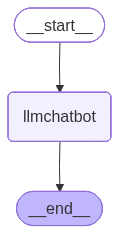

In [51]:
## Visualizing the graphh
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [52]:
response=graph.invoke({"messages":"Hi"})

In [53]:
response["messages"]

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='012675de-f72f-4356-b801-545c7d8f1b5f'),
 AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.006344138, 'completion_tokens_details': None, 'prompt_time': 0.001877252, 'prompt_tokens_details': None, 'queue_time': 0.051492378, 'total_time': 0.00822139}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee99c-07db-7a91-9fc4-2d98c39ae037-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]

In [54]:
for event in graph.stream({"messages":"Hi how are you"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content="I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or topics you'd like to discuss. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 39, 'total_tokens': 101, 'completion_time': 0.057481298, 'completion_tokens_details': None, 'prompt_time': 0.002219188, 'prompt_tokens_details': None, 'queue_time': 0.045550842, 'total_time': 0.059700486}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee99c-0987-7c52-a4ec-cebca62c08e3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 39, 'output_tokens': 62, 'total_tokens': 101})]}}


In [55]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm here and ready to help with any questions or tasks you may have. How can I assist you today?


In [56]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.datacamp.com/tutorial/langgraph-tutorial',
   'title': 'LangGraph Tutorial: What Is LangGraph and How to Use It?',
   'content': "# LangGraph Tutorial: What Is LangGraph and How to Use It? LangGraph is a library within the LangChain ecosystem that provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured and efficient manner. Imagine you're building a complex, multi-agent large language model (LLM) application. It's exciting, but it comes with challenges: managing the state of various agents, coordinating their interactions, and handling errors effectively. LangGraph provides a framework for defining, coordinating, and executing multiple LLM agents (or chains) in a structured manner. The core concepts of LangGraph include: graph structure, state management, and coordination. In LangGraph, each node represents

In [57]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [58]:
tools=[tool,multiply]

In [59]:
llm_with_tool=llm.bind_tools(tools)

In [60]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000185509934D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000018550990E90>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin

ReAct Agent Architecture

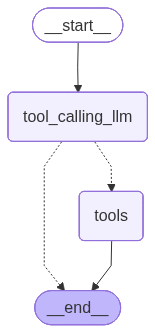

In [61]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [62]:
response=graph.invoke({"messages":"What is the recent ai news"})

In [63]:
response['messages'][-1].content

'{"query": "AI current events", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.businessinsider.com/welcome-age-ai-sprawl-too-many-tools-2026-6", "title": "Welcome to the Age of AI Sprawl - Business Insider", "score": 0.6188962, "published_date": "Sun, 21 Jun 2026 08:19:01 GMT", "content": "Tokenmaxxing became the buzzy AI word du jour this spring; as summer begins the trend is already running on empty. Amazon pulled its AI leaderboard after some employees made useless AI work to game the rankings. Palantir CEO Alex Karp likened tokenmaxxing to a porn addiction, and Duolingo walked back a decision to weigh AI use in employee performance reviews. Meta and AT&T have reportedly started curbing AI use as costs skyrocket. [...] Layoffs of thousands of workers and pivots toward AI clash with this theory. Meta, which laid off 8,000 workers last month, plans to boost its spending on AI between 60% and 87% this year, following up on its \\"year of int

In [64]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (xa6zb88dz)
 Call ID: xa6zb88dz
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
    topic: news
  tavily_search (6hwx9qgx5)
 Call ID: 6hwx9qgx5
  Args:
    query: AI current events
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://zamin.uz/en/technology/208209-nobel-laureate-john-jumper-moves-from-google-deepmind-to-anthropic.html", "title": "Nobel Laureate John Jumper Moves from Google DeepMind to Anthropic - Zamin.uz", "score": 0.6580885, "published_date": "Sat, 20 Jun 2026 16:58:51 GMT", "content": "Discuss wi

###Adding Memory In Agentic Graph

In [65]:
response=graph.invoke({"messages":"Hello my name is Shubham "})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is Shubham 
================================== Ai Message ==================================

Hello Shubham, nice to meet you. Is there something specific I can help you with today?


In [66]:
response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

Unfortunately, I don't have any information about your name. I'm a large language model, I don't have the ability to know your personal details or maintain a memory of our previous conversations. Each time you interact with me, it's a new conversation. If you'd like to share your name with me, I'd be happy to chat with you!


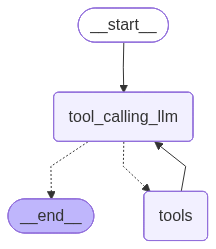

In [67]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [68]:
config={"configurable":{"thread_id":"1"}}

response=graph.invoke({"messages":"Hi my name is Shubham Kushwaha"},config=config)

response

{'messages': [HumanMessage(content='Hi my name is Shubham Kushwaha', additional_kwargs={}, response_metadata={}, id='0c91fe2c-a81b-454a-937d-1eaf75764dea'),
  AIMessage(content='Nice to meet you, Shubham Kushwaha. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1755, 'total_tokens': 1775, 'completion_time': 0.020931156, 'completion_tokens_details': None, 'prompt_time': 0.099083753, 'prompt_tokens_details': None, 'queue_time': 0.159431217, 'total_time': 0.120014909}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee9a3-777b-7c40-8d66-765121aefa8a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1755, 'output_tokens': 20, 'total_tokens': 1775})]}

In [69]:
response=graph.invoke({"messages":"Hey what is my name"},config=config)

print(response['messages'][-1].content)

Shubham Kushwaha.


In [70]:
response=graph.invoke({"messages":"Hey do you remember mmy name"},config=config)

print(response['messages'][-1].content)

Your name is Shubham Kushwaha.


### Streaming


In [71]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

In [72]:
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}

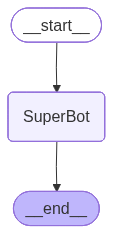

In [73]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [74]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Shubham And I like travelling"},config)

{'messages': [HumanMessage(content='Hi,My name is Shubham And I like travelling', additional_kwargs={}, response_metadata={}, id='b576781f-675d-4b45-8c06-b06eda7f9ad0'),
  AIMessage(content="Nice to meet you, Shubham. It's great to hear that you enjoy traveling. There are so many fascinating destinations and cultures to explore around the world. Have you traveled to any exciting places recently or do you have any upcoming trips planned?\n\nWhat type of travel do you enjoy the most - beach relaxation, city exploration, adventure activities, or cultural immersion?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 74, 'prompt_tokens': 47, 'total_tokens': 121, 'completion_time': 0.110786922, 'completion_tokens_details': None, 'prompt_time': 0.002284938, 'prompt_tokens_details': None, 'queue_time': 0.050832392, 'total_time': 0.11307186}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 's

Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

values : This streams the full state of the graph after each node is called.
updates : This streams updates to the state of the graph after each node is called.

In [75]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Shubham And I like watching movies"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Shubham. I'm happy to hear that you enjoy watching movies. What kind of movies do you like watching? Are you into action, romance, comedy, or perhaps science fiction?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 48, 'total_tokens': 92, 'completion_time': 0.082507854, 'completion_tokens_details': None, 'prompt_time': 0.004423387, 'prompt_tokens_details': None, 'queue_time': 0.048708143, 'total_time': 0.086931241}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee9a6-a6b9-78e3-94ef-44f3f33cfbd4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_tokens': 44, 'total_tokens': 92})]}}


In [76]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Shubham And I like Travelling"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Shubham And I like watching movies', additional_kwargs={}, response_metadata={}, id='ba8edea0-4156-4580-9916-97f04b07565a'), AIMessage(content="Nice to meet you, Shubham. I'm happy to hear that you enjoy watching movies. What kind of movies do you like watching? Are you into action, romance, comedy, or perhaps science fiction?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 48, 'total_tokens': 92, 'completion_time': 0.082507854, 'completion_tokens_details': None, 'prompt_time': 0.004423387, 'prompt_tokens_details': None, 'queue_time': 0.048708143, 'total_time': 0.086931241}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee9a6-a6b9-78e3-94ef-44f3f33cfbd4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 48, 'output_toke

In [77]:
# Create a thread
config = {"configurable": {"thread_id": "4"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Shubham And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Nice to meet you, Shubham. It's great that you like cricket. Cricket is a fantastic sport with a huge following worldwide, especially in India. Which team or player is your favorite in Indian cricket? Are you a fan of Test cricket, One-Day Internationals (ODIs), or the T20 format?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 47, 'total_tokens': 114, 'completion_time': 0.210707539, 'completion_tokens_details': None, 'prompt_time': 0.023785246, 'prompt_tokens_details': None, 'queue_time': 0.429110184, 'total_time': 0.234492785}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d9492c3c54', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee9a8-1a1f-77c2-a1dc-de2913f209d5-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 67, 'total_tokens': 114})]}}


In [ ]:
for chunk in graph_builder.stream({'messages':"I also like singing"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Shubham And I like cricket', additional_kwargs={}, response_metadata={}, id='f4947703-6582-48f2-b977-f10d84dc3cba'), AIMessage(content="Nice to meet you, Shubham. It's great that you like cricket. Cricket is a fantastic sport with a huge following worldwide, especially in India. Which team or player is your favorite in Indian cricket? Are you a fan of Test cricket, One-Day Internationals (ODIs), or the T20 format?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 47, 'total_tokens': 114, 'completion_time': 0.210707539, 'completion_tokens_details': None, 'prompt_time': 0.023785246, 'prompt_tokens_details': None, 'queue_time': 0.429110184, 'total_time': 0.234492785}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d9492c3c54', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee9a8-1a1f-77c2-a1dc-de2913f209d5-

In [79]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Shubham and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Shubham and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ee9a8-d243-7683-bfe9-2f7a392a9fef', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Shubham and I like to play cricket', additional_kwargs={}, response_metadata={}, id='1e8a9a7c-c5b1-44cf-844d-a32bccee6fdb')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019ee9a8-d24e-7990-a35e-30d2031bd76a', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:ca3ba3d6-8ebf-4fae-1442-a82e24eac682'}, 'parent_ids': ['019ee9a8-d243-7683-bfe9-2f7a392a9fef']}
{'event': 'on_chat_model_start', 'data': {'input': {'messag